In [25]:
# Import
import pandas as pd
import geopandas as gpd
from sqlalchemy import create_engine
from db_connection_test import user, pwd, host, port, database
import matplotlib.pyplot as plt
import networkx as nx
from shapely.geometry import Point
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [26]:
# Quering the database
engine_for_connection = create_engine(f'postgresql://{user}:{pwd}@{host}:{port}/{database}')

query = """
SELECT *
FROM roads_filtered
"""

# read network dataframe (edges)
edges = gpd.read_postgis(
    query,
    engine_for_connection,
    geom_col="geom"
)
# convert data
edges = edges.to_crs(epsg=32632)

In [27]:
# Building graph with networkx
edges["source"] = edges.geometry.apply(lambda x: x.coords[0])
edges["target"] = edges.geometry.apply(lambda x: x.coords[-1])

G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    edge_attr=True
)

print("# Nodes:", G.number_of_nodes())
print("# Edges:", G.number_of_edges())


# Nodes: 20002
# Edges: 19643


In [28]:
# Computing graph density
density = nx.density(G)
print(f"The density of the Turin road network is extremely low\n(the density value is {density})\nbut this is expected for spatial infrastructure networks:\neach intersection connects only a small number of\nneighboring roads, resulting in a sparse graph structure.")

The density of the Turin road network is extremely low
(the density value is 9.820026946857837e-05)
but this is expected for spatial infrastructure networks:
each intersection connects only a small number of
neighboring roads, resulting in a sparse graph structure.


In [29]:
# Building graph nodes as GeoDataFrame
nodes = set(edges["source"]).union(set(edges["target"]))
nodes_df = pd.DataFrame(list(nodes), columns=["x", "y"])
nodes_df["geometry"] = nodes_df.apply(lambda x: Point(x["x"], x["y"]), axis=1)
nodes_gdf = gpd.GeoDataFrame(nodes_df, geometry="geometry")

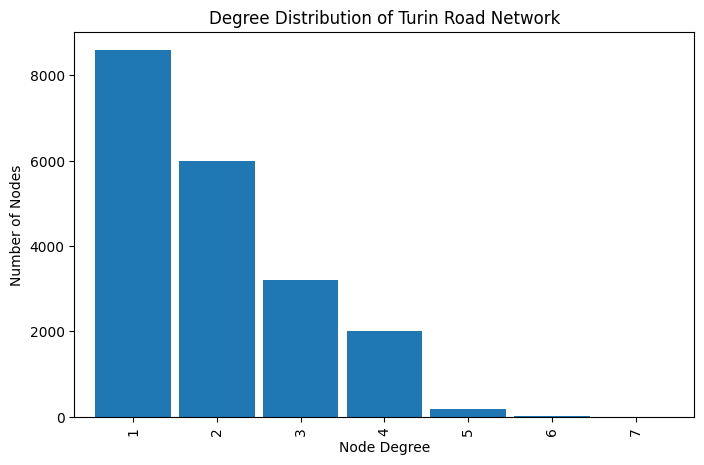

In [30]:
# Computing nodes degree
degree = dict(G.degree())
nodes_gdf["degree"] = nodes_gdf.apply(lambda x: degree.get((x.x, x.y), 0), axis=1)
degree_counts = nodes_gdf["degree"].value_counts().sort_index()
plt.figure(figsize=(8,5))
degree_counts.plot.bar(width=0.9)
plt.title("Degree Distribution of Turin Road Network")
plt.xlabel("Node Degree")
plt.ylabel("Number of Nodes")
plt.show()

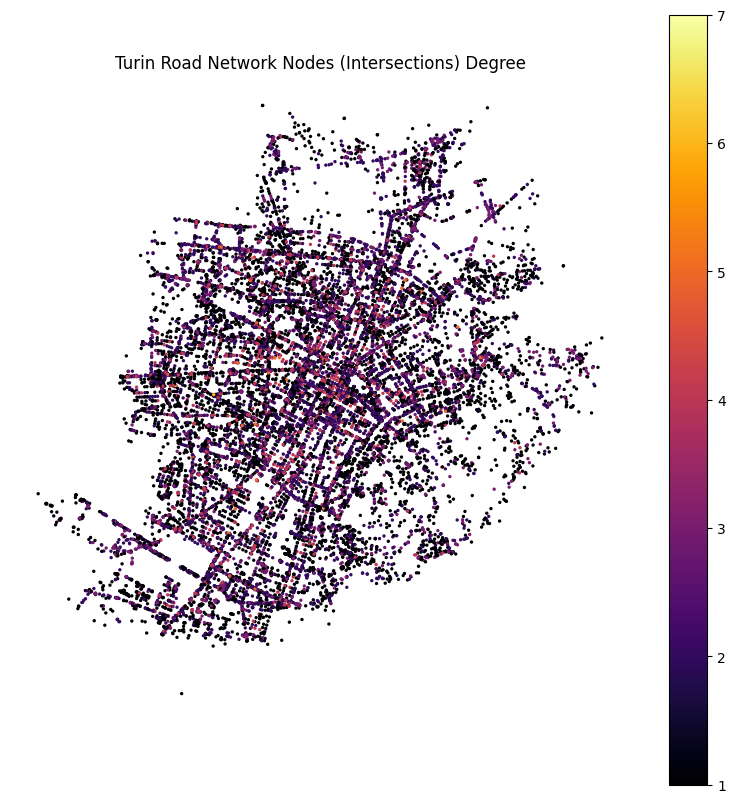

In [31]:
# Visualizing node degree
fig, ax = plt.subplots(figsize=(10,10))
nodes_gdf.plot(
    column="degree",
    cmap="inferno",
    legend=True,
    markersize=2,
    ax=ax
)
ax.set_title("Turin Road Network Nodes (Intersections) Degree")
ax.axis("off")
plt.show()

The visualization highlights the degree of intersections in the Turin road network. Most nodes have a degree of 4 or fewer, reflecting typical street layouts in which intersections connect a limited number of roads.

In [32]:
# Filtering nodes
nodes_gdf = nodes_gdf[nodes_gdf["degree"]>1]

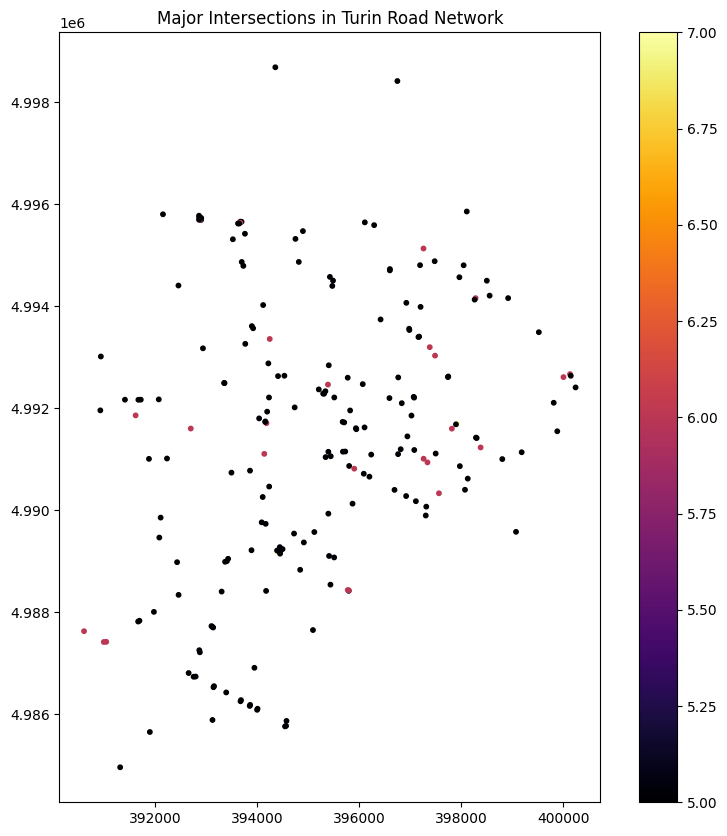

In [33]:
# Visualizing most connected nodes
intersections = nodes_gdf[nodes_gdf["degree"] >= 5]
fig, ax = plt.subplots(figsize=(10,10))
intersections.plot(
    column="degree",
    cmap="inferno",
    legend=True,
    markersize=10,
    ax=ax
)
plt.title("Major Intersections in Turin Road Network")
plt.show()

In [34]:
# Computing node centrality
centrality = nx.betweenness_centrality(G)  
# centrality measures how often a node belongs
# to the shortest paths in the network
nodes_gdf["centrality"] = nodes_gdf.apply(
    lambda x: centrality.get((x["x"], x["y"]), 0),
    axis=1
)

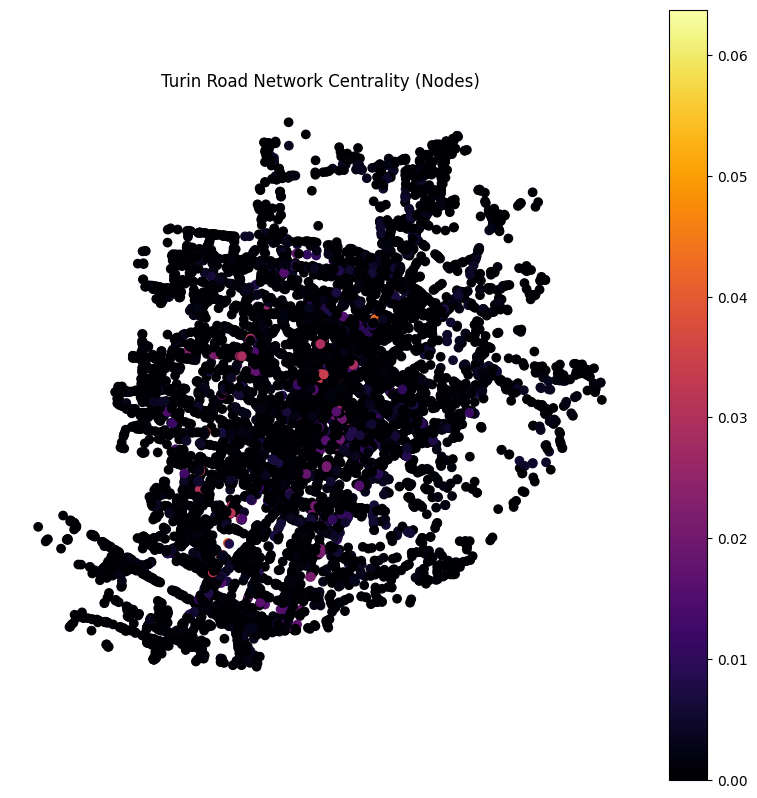

In [35]:
# Visualizing network centrality (nodes)
fig, ax = plt.subplots(figsize=(10,10))
nodes_gdf.plot(column="centrality", 
               cmap="inferno",
               legend=True,
               ax=ax)

ax.set_title("Turin Road Network Centrality (Nodes)")
ax.axis("off")

plt.show()

In [36]:
# Attaching nodes centrality to edges (defining the edges centrality)
edges["centrality"] = edges.apply(
    lambda row: (
        centrality.get(row["source"], 0) +
        centrality.get(row["target"], 0)
    ) / 2,
    axis=1
)


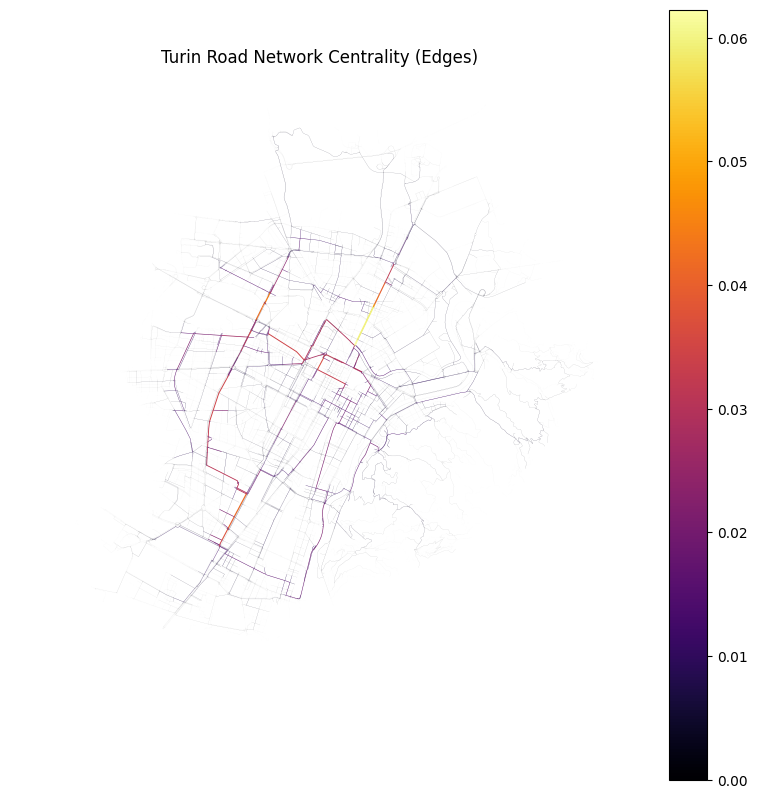

In [37]:
# Visualizing network centrality (edges)
fig, ax = plt.subplots(figsize=(10,10))
edges.plot(
    column="centrality",
    cmap="inferno",
    linewidth=edges["centrality"] * 20,
    legend=True,
    ax=ax
)

ax.set_title("Turin Road Network Centrality (Edges)")
ax.axis("off")

plt.show()

The edge betweenness centrality is used to calculate the frequency with which a road segment (edge) is used as part of the shortest path between any two locations. This metric highlights critical corridors and main arteries that are most likely to experience heavy traffic load and congestion.